In [ ]:
!pip install python-docx
!pip install pandas
!pip install scikit-learn
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd

from docx import Document

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving resume_1.docx to resume_1.docx
Saving resume_2.docx to resume_2.docx
Saving resume_3.docx to resume_3.docx
Saving resume_4.docx to resume_4.docx
Saving resume_5.docx to resume_5.docx
Saving resume_6.docx to resume_6.docx
Saving resume_7.docx to resume_7.docx
Saving resume_8.docx to resume_8.docx
Saving resume_9.docx to resume_9.docx
Saving resume_10.docx to resume_10.docx
Saving resume_11.docx to resume_11.docx
Saving resume_12.docx to resume_12.docx
Saving resume_13.docx to resume_13.docx
Saving resume_14.docx to resume_14.docx
Saving resume_15.docx to resume_15.docx
Saving resume_16.docx to resume_16.docx
Saving resume_17.docx to resume_17.docx
Saving resume_18.docx to resume_18.docx
Saving resume_19.docx to resume_19.docx
Saving resume_20.docx to resume_20.docx
Saving resume_21.docx to resume_21.docx
Saving resume_22.docx to resume_22.docx
Saving resume_23.docx to resume_23.docx
Saving resume_24.docx to resume_24.docx
Saving resume_25.docx to resume_25.docx
Saving resume_26.d

In [ ]:
def extract_resume_text(file_name):

    doc = Document(file_name)

    text = ""

    for para in doc.paragraphs:

        text += para.text + "\n"

    return text

In [ ]:
skills_db = [

    "python",
    "sql",
    "power bi",
    "excel",
    "tableau",

    "machine learning",
    "deep learning",
    "pandas",

    "html",
    "css",
    "javascript",

    "flask",
    "streamlit",

    "mysql",
    "git",
    "github",

    "aws",
    "docker",
    "linux"
]

In [ ]:
def extract_skills(text):

    found = []

    text = text.lower()

    for skill in skills_db:

        if skill in text:

            found.append(skill)

    return found

In [ ]:
job_description = """

DATA ANALYST

Required Skills:

Python
SQL
Power BI
Excel
Tableau

"""

In [ ]:
job_skills = extract_skills(
    job_description
)

print(job_skills)

['python', 'sql', 'power bi', 'excel', 'tableau']


In [ ]:
results = []

for resume in uploaded.keys():

    resume_text = extract_resume_text(
        resume
    )

    resume_skills = extract_skills(
        resume_text
    )

    matched_skills = list(
        set(resume_skills)
        &
        set(job_skills)
    )

    skill_score = (
        len(matched_skills)
        /
        len(job_skills)
    ) * 100

    docs = [
        resume_text,
        job_description
    ]

    vectorizer = TfidfVectorizer()

    matrix = vectorizer.fit_transform(
        docs
    )

    similarity_score = (
        cosine_similarity(
            matrix[0],
            matrix[1]
        )[0][0]
    ) * 100

    ats_score = (
        0.7 * skill_score
        +
        0.3 * similarity_score
    )

    results.append({

        "Candidate": resume,

        "ATS Score":
        round(ats_score,2),

        "Matched Skills":
        len(matched_skills)
    })

print("Screening Completed")

Screening Completed


In [ ]:
df = pd.DataFrame(results)

df = df.sort_values(
    by="ATS Score",
    ascending=False
)

df["Rank"] = range(
    1,
    len(df)+1
)

df

,Candidate,ATS Score,Matched Skills,Rank
25,resume_26.docx,82.76,5,1
12,resume_13.docx,82.62,5,2
24,resume_25.docx,82.01,5,3
2,resume_3.docx,81.83,5,4
11,resume_12.docx,81.57,5,5
4,resume_5.docx,67.74,4,6
21,resume_22.docx,67.60,4,7
5,resume_6.docx,66.66,4,8
16,resume_17.docx,66.30,4,9
10,resume_11.docx,65.98,4,10


In [ ]:
df["Status"] = df["ATS Score"].apply(

    lambda x:
    "Selected"
    if x >= 60
    else "Rejected"
)

df.head()

,Candidate,ATS Score,Matched Skills,Rank,Status
25,resume_26.docx,82.76,5,1,Selected
12,resume_13.docx,82.62,5,2,Selected
24,resume_25.docx,82.01,5,3,Selected
2,resume_3.docx,81.83,5,4,Selected
11,resume_12.docx,81.57,5,5,Selected


In [ ]:
candidate = df.iloc[0]["Candidate"]

resume_text = extract_resume_text(
    candidate
)

resume_skills = extract_skills(
    resume_text
)

missing_skills = list(

    set(job_skills)
    -
    set(resume_skills)
)

print("Top Candidate:")
print(candidate)

print()

print("Missing Skills:")
print(missing_skills)

Top Candidate:
resume_26.docx

Missing Skills:
[]


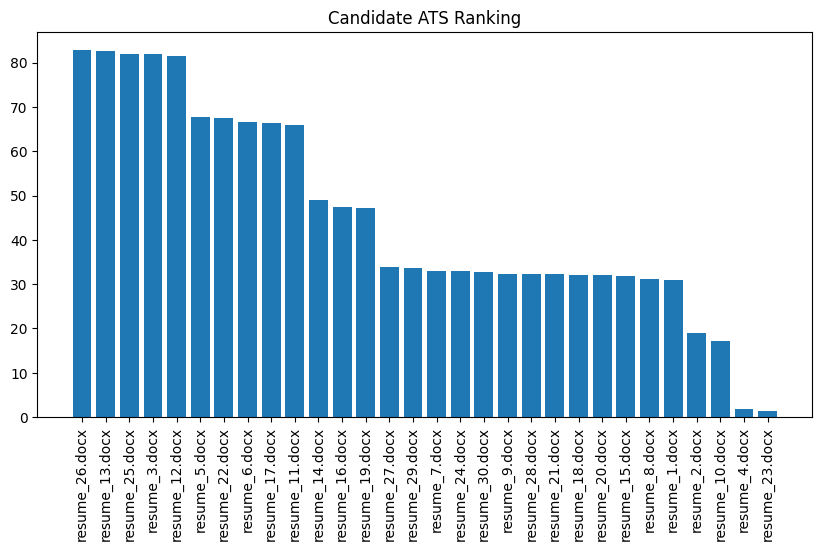

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    df["Candidate"],
    df["ATS Score"]
)

plt.xticks(rotation=90)

plt.title(
    "Candidate ATS Ranking"
)

plt.show()

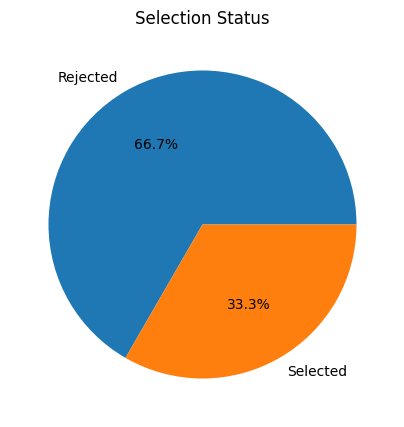

In [ ]:
status_count = (
    df["Status"]
    .value_counts()
)

plt.figure(figsize=(5,5))

plt.pie(

    status_count,

    labels=status_count.index,

    autopct='%1.1f%%'
)

plt.title(
    "Selection Status"
)

plt.show()

In [ ]:
df.to_csv(
    "candidate_ranking.csv",
    index=False
)

print(
    "CSV Generated Successfully"
)

CSV Generated Successfully


In [ ]:
from google.colab import files

files.download("candidate_ranking.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>